# 08 — Monthly revenue by visit type, with month-over-month change

Monthly paid revenue (`payment_status = 'completed'`, `visit_paid = 1`), split by `visit_type` (`1` = first visit, `2` = checkup), with the revenue change vs. the prior month for the same visit type via a CTE plus `LAG()`. Mirrors `docs/Client_Querires.md` §2.1.

In [ ]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import pandas as pd

load_dotenv()

engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [2]:
query = """
WITH monthly_revenue AS (
  SELECT
    DATE_FORMAT(payment_date, '%Y-%m-01') AS revenue_month,
    visit_type,                              -- '1' = first visit, '2' = checkup
    SUM(amount) AS total_revenue,
    COUNT(*) AS paid_visits
  FROM client_payments
  WHERE payment_status = 'completed'
    AND visit_paid = 1
  GROUP BY revenue_month, visit_type
)
SELECT
  revenue_month,
  visit_type,
  paid_visits,
  total_revenue,
  total_revenue - LAG(total_revenue) OVER (
    PARTITION BY visit_type ORDER BY revenue_month
  ) AS revenue_change_vs_prev_month
FROM monthly_revenue
ORDER BY revenue_month, visit_type;
"""

# text() routes this through SQLAlchemy's compiler instead of PyMySQL's raw
# `%`-mogrify, which otherwise chokes on the literal `%Y`/`%m` in DATE_FORMAT.
df = pd.read_sql(text(query), engine, parse_dates=["revenue_month"])
print(df)

  revenue_month visit_type  paid_visits  total_revenue  \
0    2026-01-01          1            2           10.0   
1    2026-02-01          1            2           10.0   
2    2026-02-01          2            3            6.0   
3    2026-03-01          1            7           35.0   
4    2026-04-01          1            5           25.0   
5    2026-04-01          2            1            2.0   
6    2026-05-01          1            8           40.0   
7    2026-07-01          1            2           10.0   

   revenue_change_vs_prev_month  
0                           NaN  
1                           0.0  
2                           NaN  
3                          25.0  
4                         -10.0  
5                          -4.0  
6                          15.0  
7                         -30.0  


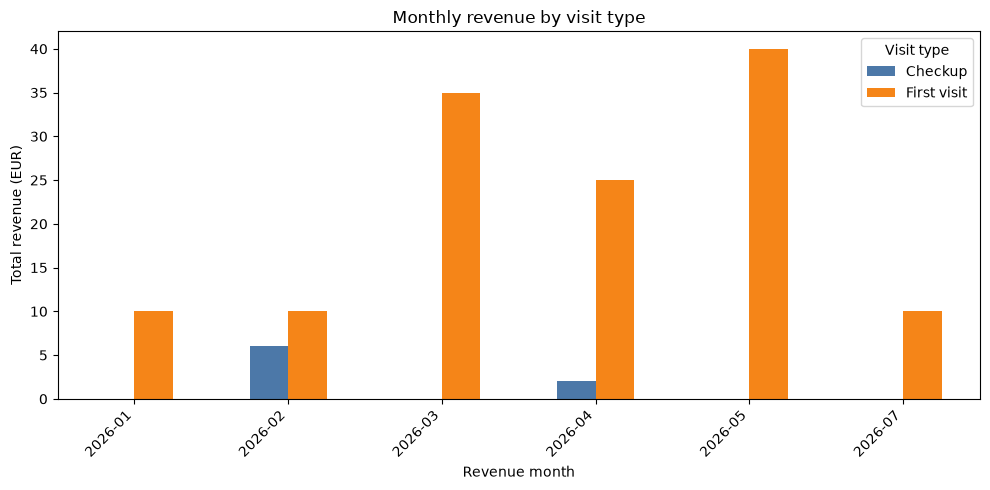

In [3]:
%matplotlib inline
import os
import matplotlib.pyplot as plt

visit_type_labels = {"1": "First visit", "2": "Checkup"}
df["visit_type_label"] = df["visit_type"].map(visit_type_labels)

pivot = df.pivot(index="revenue_month", columns="visit_type_label", values="total_revenue").fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind="bar", ax=ax, color=["#4C78A8", "#F58518"])
ax.set_xlabel("Revenue month")
ax.set_ylabel("Total revenue (EUR)")
ax.set_title("Monthly revenue by visit type")
ax.set_xticklabels([d.strftime("%Y-%m") for d in pivot.index], rotation=45, ha="right")
ax.legend(title="Visit type")
fig.tight_layout()

os.makedirs("../assets/img", exist_ok=True)
fig.savefig("../assets/img/monthly_revenue_by_visit_type.png", dpi=150)
plt.show()